# Cleaning and Transforming FIFA Players Dataset

Dataset: https://www.kaggle.com/datasets/yagunnersya/fifa-21-messy-raw-dataset-for-cleaning-exploring?resource=download&select=fifa21_raw_data.csv

In [3]:
#Importing pandas and matplotlib packages
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Reading the data into a pandas data frame
fifa_df = pd.read_csv('fifa21_raw_data_v2.csv', dtype = str) 
fifa_df.head()

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,...,High,Medium,5 ★,91,85,86,94,36,59,595


### Changing height and weight column in the data frame to numeric data types

In [6]:
fifa_df[["Height", "Weight"]]

,Height,Weight
0,170cm,72kg
1,187cm,83kg
2,188cm,87kg
3,181cm,70kg
4,175cm,68kg
...,...,...
18974,178cm,66kg
18975,175cm,65kg
18976,179cm,74kg
18977,175cm,69kg


In [7]:
fifa_df["Height"] = pd.to_numeric(fifa_df["Height"].str.replace("cm", ""), errors = "coerce")

fifa_df["Weight"] = pd.to_numeric(fifa_df["Weight"].str.replace("kg", ""), errors = "coerce")

In [8]:
print("Data type of height column is " + str(fifa_df["Height"].dtype))
print("Data type of height column is " + str(fifa_df["Weight"].dtype))

Data type of height column is float64
Data type of height column is float64


In [9]:
fifa_df[["Height", "Weight"]]

,Height,Weight
0,170.0,72.0
1,187.0,83.0
2,188.0,87.0
3,181.0,70.0
4,175.0,68.0
...,...,...
18974,178.0,66.0
18975,175.0,65.0
18976,179.0,74.0
18977,175.0,69.0


### Splitting the dates in the Joined column into separate day, month, and year columns

In [11]:
#Converting the Joined column into a date variable type using pd.to_datetime
fifa_df["Joined"] = pd.to_datetime(fifa_df["Joined"])

In [12]:
#Getting the month, day and year values from the joined column and assigning them to their individual column. 
fifa_df["Year Joined"] = fifa_df["Joined"].dt.year
fifa_df["Month Joined"] = fifa_df["Joined"].dt.month
fifa_df["Day Joined"] = fifa_df["Joined"].dt.day

fifa_df[["Joined", "Year Joined", "Month Joined", "Day Joined"]]

,Joined,Year Joined,Month Joined,Day Joined
0,2004-07-01,2004,7,1
1,2018-07-10,2018,7,10
2,2014-07-16,2014,7,16
3,2015-08-30,2015,8,30
4,2017-08-03,2017,8,3
...,...,...,...,...
18974,2018-07-13,2018,7,13
18975,2020-08-01,2020,8,1
18976,2019-03-08,2019,3,8
18977,2020-09-22,2020,9,22


### Cleaning the Value, Wage and Release Clause columns which contained currencies; converted to integers.

In [14]:
print(fifa_df[["Value", "Wage", "Release Clause"]])
print(fifa_df[["Value", "Wage", "Release Clause"]].dtypes)

         Value   Wage Release Clause
0      €103.5M  €560K        €138.4M
1         €63M  €220K         €75.9M
2        €120M  €125K        €159.4M
3        €129M  €370K          €161M
4        €132M  €270K        €166.5M
...        ...    ...            ...
18974    €100K    €1K           €70K
18975    €130K   €500          €165K
18976    €120K   €500          €131K
18977    €100K    €2K           €88K
18978    €100K    €1K           €79K

[18979 rows x 3 columns]
Value             object
Wage              object
Release Clause    object
dtype: object


In [15]:
#Defining a function that converts the currency format to an integer format
def money_to_int(x): 
    x = x.replace("€", "").strip()

    #For observations in thousands
    if x.endswith("K"):
        return float(x[:-1]) * 1000
    #For observations in millions
    if x.endswith("M"):
        return float(x[:-1]) * 1000000

    return float(x)

In [16]:
#Applying the function to the columns
fifa_df["Wage"] = fifa_df["Wage"].apply(money_to_int)
fifa_df["Value"] = fifa_df["Value"].apply(money_to_int)
fifa_df["Release Clause"] = fifa_df["Release Clause"].apply(money_to_int)

In [17]:
fifa_df[["Value", "Wage", "Release Clause"]]

,Value,Wage,Release Clause
0,103500000.0,560000.0,138400000.0
1,63000000.0,220000.0,75900000.0
2,120000000.0,125000.0,159400000.0
3,129000000.0,370000.0,161000000.0
4,132000000.0,270000.0,166500000.0
...,...,...,...
18974,100000.0,1000.0,70000.0
18975,130000.0,500.0,165000.0
18976,120000.0,500.0,131000.0
18977,100000.0,2000.0,88000.0


### Removing unecessary characters from columns

In [19]:
fifa_df[["W/F", "SM", "IR"]]

,W/F,SM,IR
0,4 ★,4★,5 ★
1,4 ★,5★,5 ★
2,3 ★,1★,3 ★
3,5 ★,4★,4 ★
4,5 ★,5★,5 ★
...,...,...,...
18974,2 ★,2★,1 ★
18975,2 ★,2★,1 ★
18976,2 ★,2★,1 ★
18977,3 ★,2★,1 ★


In [20]:
fifa_df["W/F"] = fifa_df["W/F"].str.replace("★", "").str.strip()
fifa_df["SM"] = fifa_df["SM"].str.replace("★", "").str.strip()
fifa_df["IR"] = fifa_df["IR"].str.replace("★", "").str.strip()

fifa_df[["W/F", "SM", "IR"]]

,W/F,SM,IR
0,4,4,5
1,4,5,5
2,3,1,3
3,5,4,4
4,5,5,5
...,...,...,...
18974,2,2,1
18975,2,2,1
18976,2,2,1
18977,3,2,1


### Removing the newline characters from the club column

In [22]:
fifa_df["Club"]

0               \n\n\n\nFC Barcelona
1                   \n\n\n\nJuventus
2            \n\n\n\nAtlético Madrid
3            \n\n\n\nManchester City
4        \n\n\n\nParis Saint-Germain
                    ...             
18974             \n\n\n\nWuhan Zall
18975        \n\n\n\nOldham Athletic
18976             \n\n\n\nDerry City
18977       \n\n\n\nDalian YiFang FC
18978       \n\n\n\nDalian YiFang FC
Name: Club, Length: 18979, dtype: object

In [23]:
fifa_df["Club"] = fifa_df["Club"].str.replace("\n", "", regex = False).str.strip()
fifa_df["Club"]

0               FC Barcelona
1                   Juventus
2            Atlético Madrid
3            Manchester City
4        Paris Saint-Germain
                ...         
18974             Wuhan Zall
18975        Oldham Athletic
18976             Derry City
18977       Dalian YiFang FC
18978       Dalian YiFang FC
Name: Club, Length: 18979, dtype: object

### Looking at missing values

In [25]:
print((fifa_df.isnull().sum()/fifa_df.shape[0])*100)

ID               0.000000
Name             0.000000
LongName         0.000000
photoUrl         0.000000
playerUrl        0.000000
                  ...    
PHY              0.000000
Hits            13.673007
Year Joined      0.000000
Month Joined     0.000000
Day Joined       0.000000
Length: 80, dtype: float64


Here we can get a sense of how many missing values are there in the data set. All of the data seems to not have high proportions of missing values except the Loan Date End column. Since we don't know the reason for why this column has so much missing data, we will leave it as such. For the other columns 

In [27]:
# Dropping the Loan Date End colunn
fifa = fifa_df.drop("Loan Date End", axis = 1) 

In [28]:
fifa[fifa.isna().any(axis=1)] 

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Year Joined,Month Joined,Day Joined
793,110677,Moyá,Miguel Ángel Moyá Rumbo,https://cdn.sofifa.com/players/110/677/21_60.png,http://sofifa.com/player/110677/miguel-angel-m...,Spain,36,78,78,Real Sociedad,...,82,72,80,78,39,79,14,2018,2,27
847,166706,M. Škrtel,Martin Škrtel,https://cdn.sofifa.com/players/166/706/21_60.png,http://sofifa.com/player/166706/martin-skrtel/...,Slovakia,35,78,78,Medipol Başakşehir FK,...,47,38,48,51,78,82,22,2020,8,20
848,189068,B. Dost,Bas Dost,https://cdn.sofifa.com/players/189/068/21_60.png,http://sofifa.com/player/189068/bas-dost/210005/,Netherlands,31,78,78,Eintracht Frankfurt,...,47,81,57,65,51,79,33,2019,8,26
860,198031,Sérgio Oliveira,Sérgio Miguel Relvas de Oliveira,https://cdn.sofifa.com/players/198/031/21_60.png,http://sofifa.com/player/198031/sergio-miguel-...,Portugal,28,78,78,FC Porto,...,58,77,82,75,66,68,41,2015,7,1
861,190243,M. Hitz,Marwin Hitz,https://cdn.sofifa.com/players/190/243/21_60.png,http://sofifa.com/player/190243/marwin-hitz/21...,Switzerland,32,78,78,Borussia Dortmund,...,79,77,63,80,44,79,17,2018,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18974,247223,Xia Ao,Ao Xia,https://cdn.sofifa.com/players/247/223/21_60.png,http://sofifa.com/player/247223/ao-xia/210006/,China PR,21,47,55,Wuhan Zall,...,64,28,26,38,48,51,NaN,2018,7,13
18975,258760,B. Hough,Ben Hough,https://cdn.sofifa.com/players/258/760/21_60.png,http://sofifa.com/player/258760/ben-hough/210006/,England,17,47,67,Oldham Athletic,...,64,40,48,49,35,45,NaN,2020,8,1
18976,252757,R. McKinley,Ronan McKinley,https://cdn.sofifa.com/players/252/757/21_60.png,http://sofifa.com/player/252757/ronan-mckinley...,England,18,47,65,Derry City,...,63,39,44,46,40,53,NaN,2019,3,8
18977,243790,Wang Zhen'ao,Zhen'ao Wang,https://cdn.sofifa.com/players/243/790/21_60.png,http://sofifa.com/player/243790/zhenao-wang/21...,China PR,20,47,57,Dalian YiFang FC,...,58,49,41,49,30,44,NaN,2020,9,22


In [29]:
# Assume that the missing hits values are just zero
fifa["Hits"] = fifa["Hits"].fillna(0)

The final cleaning step here imputes the missing height and weight data of the different players by using the average of all other players of the same nationality. 

In [31]:
cols = ["Height", "Weight"]

fifa[cols] = fifa.groupby("Nationality")[cols].transform(
    lambda x: x.fillna(x.mean())
)

Creating a simple plot using wage and value to see if certain players are over or overvalued. 

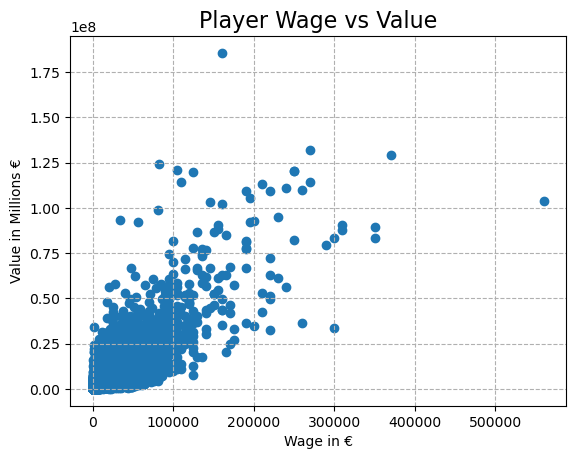

In [33]:
plt.scatter(fifa["Wage"], fifa["Value"])

plt.title('Player Wage vs Value', fontsize=16)
plt.xlabel('Wage in €')
plt.ylabel('Value in Millions €')
plt.grid(True, linestyle='--')
plt.show()

- Shown here generally the majority of players are valued under half a million and makes less than 150k.
- From looking at the graph it does seem that most players are fairly valued as the dots lie in a weakly positive linear trend
- There are some  outliers of players who are highly valued yet has a lower wage than expected and vice versa